# 22-liver-clonotype-clustering

In [21]:
import scanpy as sc
import scirpy as ir
import numpy as np
import json
from pathlib import Path
import pandas as pd
import muon as mu
import anndata as ad
import re
import warnings
from cycler import cycler
from matplotlib import cm as mpl_cm
from matplotlib import pyplot as plt

warnings.filterwarnings('ignore')

DATA = Path("data")

In [2]:
def read_vdj(path: Path):
  adata = ir.io.read_10x_vdj(path)
  ir.pp.index_chains(adata)
  ir.tl.chain_qc(adata)
  return adata

def read_sample(path: Path) -> tuple[ad.AnnData, ad.AnnData, ad.AnnData]:
  mtx = next(path.glob("*_GEX_matrix.mtx.gz"))
  prefix = mtx.name[: -len("matrix.mtx.gz")]

  adata_gex = sc.read_10x_mtx(path, var_names="gene_symbols", prefix=prefix)
  adata_gex.var_names_make_unique()
  sc.pp.filter_cells(adata_gex, min_genes=200)
  sc.pp.filter_genes(adata_gex, min_cells=3)
  adata_gex.var["mt"] = adata_gex.var_names.str.startswith("MT-")
  sc.pp.calculate_qc_metrics(adata_gex, qc_vars=["mt"], inplace=True, log1p=True)
  mu.pp.filter_obs(adata_gex, 'pct_counts_mt', lambda x: x < 10)

  adata_tcr = read_vdj(next(path.glob("*_TCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_tcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_tcr, "chain_pairing", lambda x: x == "single pair")

  adata_bcr = read_vdj(next(path.glob("*_BCR_filtered_contig_annotations.csv.gz")))
  mu.pp.filter_obs(adata_bcr, "receptor_subtype", lambda x: ~np.isin(x, ["multichain", "ambiguous", "no IR"]))
  mu.pp.filter_obs(adata_bcr, "chain_pairing", lambda x: x == "single pair")

  return adata_gex, adata_tcr, adata_bcr


In [3]:
SAMPLE_RE = re.compile(r"Patient(\d+)-(.+)")

adatas_gex = {}
adatas_tcr = {}
adatas_bcr = {}

for sample_dir in sorted(DATA.glob("*/*")):
  if not sample_dir.is_dir():
    continue

  match = SAMPLE_RE.fullmatch(sample_dir.name)
  if not match:
    continue

  sample = sample_dir.name
  patient, condition = match.group(1), match.group(2)
  status = sample_dir.parent.name

  gex, tcr, bcr = read_sample(sample_dir)

  for adata in (gex, tcr, bcr):
    adata.obs["sample"] = sample
    adata.obs["patient"] = patient
    adata.obs["condition"] = condition
    adata.obs["status"] = status
    adata.obs["pre_transplant"] = status == "Pre-TXP"

  adatas_gex[sample] = gex
  adatas_tcr[sample] = tcr
  adatas_bcr[sample] = bcr

adata_gex = ad.concat(adatas_gex, index_unique="_")
adata_tcr = ad.concat(adatas_tcr, index_unique="_")
adata_bcr = ad.concat(adatas_bcr, index_unique="_")

mdata = mu.MuData({
  "gex": adata_gex,
  "tcr": adata_tcr,
  "bcr": adata_bcr,
})

mdata


MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [4]:
ir.pp.ir_dist(mdata, airr_mod="tcr")
ir.tl.define_clonotypes(mdata, airr_mod="tcr", receptor_arms="all", dual_ir="primary_only")
mdata

MuData object with n_obs × n_vars = 10521 × 4829
  3 modalities
    gex:	7194 × 4829
      obs:	'n_genes', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_mt', 'log1p_total_counts_mt', 'pct_counts_mt', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      layers:	None
    tcr:	2332 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant', 'clone_id', 'clone_id_size'
      uns:	'ir_dist_nt_identity', 'clone_id'
      obsm:	'airr', 'chain_indices'
    bcr:	3122 × 0
      obs:	'receptor_type', 'receptor_subtype', 'chain_pairing', 'sample', 'patient', 'condition', 'status', 'pre_transplant'
      obsm:	'airr', 'chain_indices'

In [5]:
ir.pp.ir_dist(
  mdata,
  airr_mod="tcr",
  metric="tcrdist",
  sequence="aa",
  cutoff=15,
)

ir.tl.define_clonotype_clusters(mdata, airr_mod="tcr", sequence="aa", metric="tcrdist", receptor_arms="all", dual_ir="any")

ir.tl.clonotype_network(mdata, airr_mod="tcr", min_cells=3, sequence="aa", metric="tcrdist")

In [8]:
mdata['gex'].layers['counts'] = mdata['gex'].X.copy()
sc.pp.normalize_total(mdata['gex'], target_sum=1e4)
sc.pp.log1p(mdata['gex'])
sc.pp.highly_variable_genes(mdata["gex"], flavor="cell_ranger", n_top_genes=5000)
sc.tl.pca(mdata["gex"])
sc.pp.neighbors(mdata["gex"])
sc.tl.umap(mdata["gex"])

In [10]:
ir.tl.clonotype_modularity(mdata, target_col="tcr:cc_aa_tcrdist", airr_mod="tcr")

  0%|          | 0/1229 [00:00<?, ?it/s]

  0%|          | 0/1000 [00:00<?, ?it/s]

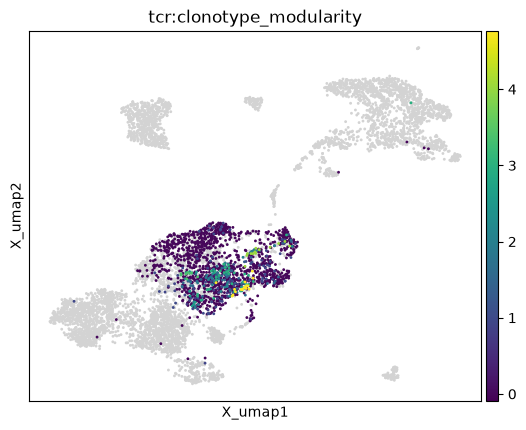

In [11]:
mu.pl.embedding(mdata, basis="gex:umap", color="tcr:clonotype_modularity")

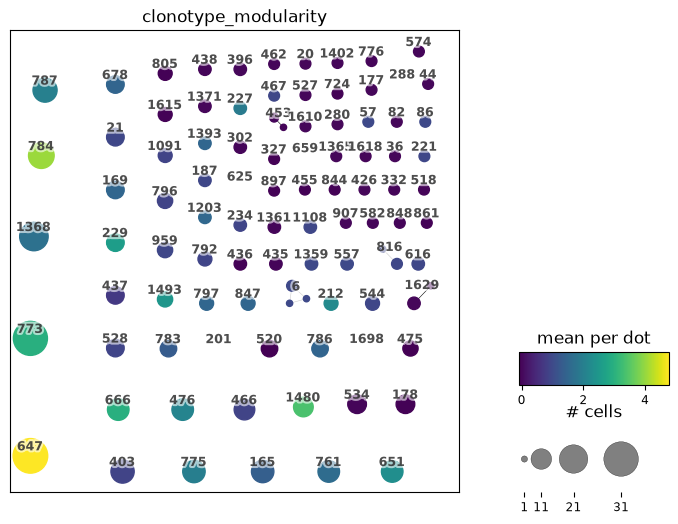

In [12]:
_ = ir.pl.clonotype_network(
    mdata,
    airr_mod="tcr",
    color="clonotype_modularity",
    label_fontsize=9,
    panel_size=(6, 6),
    base_size=20,
)

findfont: Failed to find font weight 300, now using 400.


<Axes: xlabel='modularity score', ylabel='-log10(FDR)'>

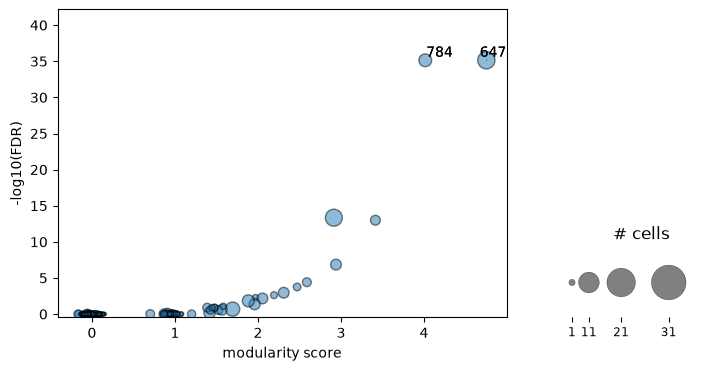

In [16]:
ir.pl.clonotype_modularity(mdata, base_size=20, airr_mod="tcr")

In [13]:
mdata.obs.head()

,gex:n_genes,gex:n_genes_by_counts,gex:log1p_n_genes_by_counts,gex:total_counts,gex:log1p_total_counts,gex:pct_counts_in_top_50_genes,gex:pct_counts_in_top_100_genes,gex:pct_counts_in_top_200_genes,gex:pct_counts_in_top_500_genes,gex:total_counts_mt,...,bcr:patient,bcr:condition,bcr:status,bcr:pre_transplant,tcr:clone_id,tcr:clone_id_size,tcr:cc_aa_tcrdist,tcr:cc_aa_tcrdist_size,tcr:clonotype_modularity,tcr:clonotype_modularity_fdr
AAACCTGAGACTACAA-1_Patient10-BX1,1366,1361,7.216709,3429,8.140316,37.270341,49.139691,60.309128,74.890639,314,...,NaN,NaN,NaN,<NA>,0,1.0,0,1.0,0.0,1.0
AAACCTGTCCGCGGTA-1_Patient10-BX1,2918,2826,7.946971,7925,8.977903,27.545741,37.753943,48.037855,62.826498,520,...,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
AAACGGGGTACTTCTT-1_Patient10-BX1,783,782,6.663133,1374,7.226209,33.697234,44.759825,57.641921,79.475983,94,...,NaN,NaN,NaN,<NA>,2,1.0,2,1.0,0.0,1.0
AAAGATGTCAGCTCGG-1_Patient10-BX1,2561,2555,7.846199,9909,9.201300,36.169139,50.015138,61.459279,73.781411,457,...,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,NaN,NaN,NaN
AAAGCAACACAGCCCA-1_Patient10-BX1,4000,3996,8.293299,18252,9.812085,28.117467,39.086128,50.454745,64.732632,780,...,NaN,NaN,NaN,<NA>,4,1.0,4,1.0,0.0,1.0


In [27]:
def mean_modularity(mdata: mu.MuData, sample: str) -> float:
  obs = mdata.obs
  obs = obs[obs['tcr:sample']  == sample]
  return obs['tcr:clonotype_modularity'].mean()

mean_modularity_patient12_bx2 = mean_modularity(mdata, 'Patient12-BX2')
mean_modularity_patient12_bx3 = mean_modularity(mdata, 'Patient12-BX3')
mean_modularity_patient12_bx5 = mean_modularity(mdata, 'Patient12-BX5')
delta_mean_modularity_patient12 = abs(mean_modularity_patient12_bx5 - mean_modularity_patient12_bx2)

print(f"Patient12-BX2 mean clonotype modularity: {mean_modularity_patient12_bx2}")
print(f"Patient12-BX3 mean clonotype modularity: {mean_modularity_patient12_bx3}")
print(f"Patient12-BX5 mean clonotype modularity: {mean_modularity_patient12_bx5}")
print(f"Patient 12 delta mean clonotype modularity: {delta_mean_modularity_patient12}")


Patient12-BX2 mean clonotype modularity: 0.28693514145328225
Patient12-BX3 mean clonotype modularity: 0.2833237191374835
Patient12-BX5 mean clonotype modularity: 0.243348026624083
Patient 12 delta mean clonotype modularity: 0.04358711482919925


In [17]:
clonotypes_top_modularity = list(
    mdata.obs.set_index("tcr:cc_aa_tcrdist")["tcr:clonotype_modularity"]
    .sort_values(ascending=False)
    .index.unique()
    .values[:2]
)

clonotypes_top_modularity

['647', '784']

In [41]:
obs = mdata['tcr'].obs
obs = obs[obs['cc_aa_tcrdist'].isin(clonotypes_top_modularity)]
obs

,receptor_type,receptor_subtype,chain_pairing,sample,patient,condition,status,pre_transplant,clone_id,clone_id_size,cc_aa_tcrdist,cc_aa_tcrdist_size,clonotype_modularity,clonotype_modularity_fdr
cell_id,,,,,,,,,,,,,,
AAGCCGCCAGGTTTCA-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
AAGGTTCCACGCATCG-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
ACGAGGAGTACACCGC-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
ACTTACTTCCGAGCCA-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
AGACGTTGTCCGTTAA-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
AGAGCTTGTGTAACGG-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
ATTGGACCATTCCTCG-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
CACATAGCAAGCTGAG-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36
CCGTGGAAGCACGCCT-1_Patient13-BX1,TCR,TRA+TRB,single pair,Patient13-BX1,13,BX1,Late-ACR,False,650,31,647,31,4.764665,7.223413e-36


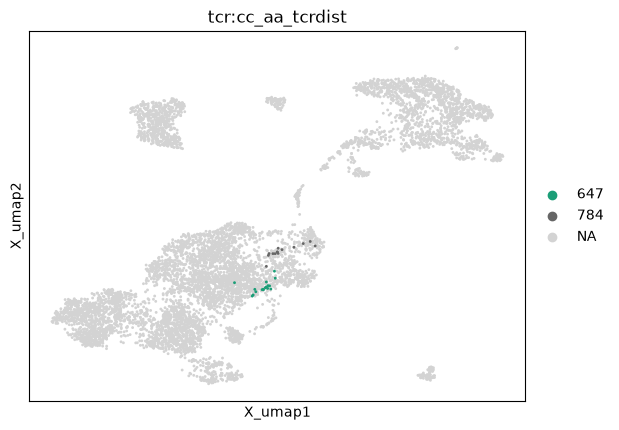

In [19]:
test_ad = mu.pl.embedding(
  mdata,
  basis="gex:umap",
  color="tcr:cc_aa_tcrdist",
  groups=clonotypes_top_modularity,
  palette=cycler(color=mpl_cm.Dark2_r.colors),
)

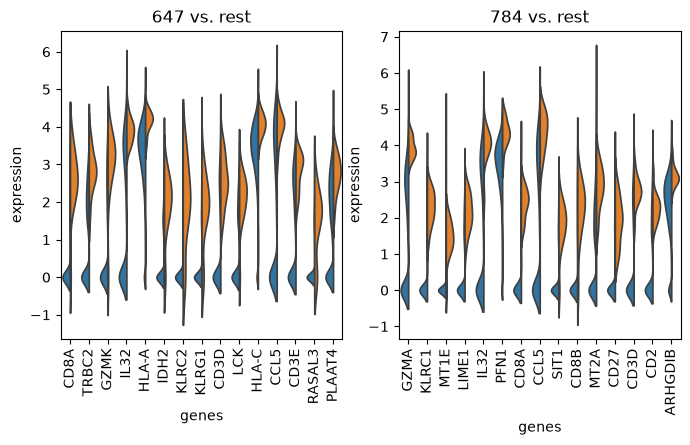

In [22]:
with ir.get.obs_context(mdata["gex"], {"cc_aa_tcrdist": mdata.obs["tcr:cc_aa_tcrdist"]}) as tmp_ad:
    sc.tl.rank_genes_groups(
        tmp_ad,
        "cc_aa_tcrdist",
        groups=clonotypes_top_modularity,
        reference="rest",
        method="wilcoxon",
    )
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))
    for ct, ax in zip(clonotypes_top_modularity, axs, strict=False):
        sc.pl.rank_genes_groups_violin(tmp_ad, groups=[ct], n_genes=15, ax=ax, show=False, strip=False)